In [1]:
!git clone https://github.com/hani-rahmoune/pharma-safety-lakehouse.git
%cd pharma-safety-lakehouse
!pip install -r requirements.txt

Cloning into 'pharma-safety-lakehouse'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 128 (delta 55), reused 102 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 6.99 MiB | 10.70 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/pharma-safety-lakehouse
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of apache-airflow-providers-fab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of apache-airflow-providers-fab to determine which version is compatible 

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery

PROJECT_ID = "pharma-safety-lakehouse"
DATASET_ID = "pharma_safety_gold"

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.ml_features`
"""

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(4000, 9)


,safety_report_id,report_date,country,patient_sex,patient_age,is_serious,num_drugs,has_suspect_drug,num_reactions
0,23353582,2024-01-01,US,Female,50,0,8,1,1
1,23353582,2024-01-01,US,Female,50,0,8,1,1
2,23353582,2024-01-01,US,Female,50,0,8,1,1
3,23353582,2024-01-01,US,Female,50,0,8,1,1
4,23353584,2024-01-01,US,Male,<NA>,0,1,1,1


In [4]:
drug_summary = client.query(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.drug_summary`
""").to_dataframe()

reaction_summary = client.query(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.reaction_summary`
""").to_dataframe()

safety_overview = client.query(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.safety_overview`
""").to_dataframe()

In [5]:
df.info()
df.head()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   safety_report_id  4000 non-null   object
 1   report_date       4000 non-null   dbdate
 2   country           3976 non-null   object
 3   patient_sex       3396 non-null   object
 4   patient_age       2428 non-null   Int64 
 5   is_serious        4000 non-null   Int64 
 6   num_drugs         4000 non-null   Int64 
 7   has_suspect_drug  4000 non-null   Int64 
 8   num_reactions     4000 non-null   Int64 
dtypes: Int64(5), dbdate(1), object(3)
memory usage: 300.9+ KB


Index(['safety_report_id', 'report_date', 'country', 'patient_sex',
       'patient_age', 'is_serious', 'num_drugs', 'has_suspect_drug',
       'num_reactions'],
      dtype='object')

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ID = "pharma-safety-lakehouse"
DATASET_ID = "pharma_safety_gold"
TABLE_ID = "ml_features"

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

df = client.query(query).to_dataframe()

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

if "is_serious" in df.columns:
    print(f"\nClass balance:")
    print(df["is_serious"].value_counts())
    print(f"\nSeriousness rate: {df['is_serious'].mean():.1%}")
else:
    print("\nColumn 'is_serious' not found. Available columns:")
    print(df.columns)

df.head()

Shape: (4000, 9)

Columns: ['safety_report_id', 'report_date', 'country', 'patient_sex', 'patient_age', 'is_serious', 'num_drugs', 'has_suspect_drug', 'num_reactions']

Class balance:
is_serious
1    2084
0    1916
Name: count, dtype: Int64

Seriousness rate: 52.1%


,safety_report_id,report_date,country,patient_sex,patient_age,is_serious,num_drugs,has_suspect_drug,num_reactions
0,23353582,2024-01-01,US,Female,50,0,8,1,1
1,23353582,2024-01-01,US,Female,50,0,8,1,1
2,23353582,2024-01-01,US,Female,50,0,8,1,1
3,23353582,2024-01-01,US,Female,50,0,8,1,1
4,23353584,2024-01-01,US,Male,<NA>,0,1,1,1


In [8]:
df.to_parquet("/content/ml_features.parquet", index=False)

In [9]:
null_rates = df.isnull().mean().sort_values(ascending=False) * 100
print("Null rates (%):")
print(null_rates[null_rates > 0])

Null rates (%):
patient_age    39.3
patient_sex    15.1
country         0.6
dtype: float64


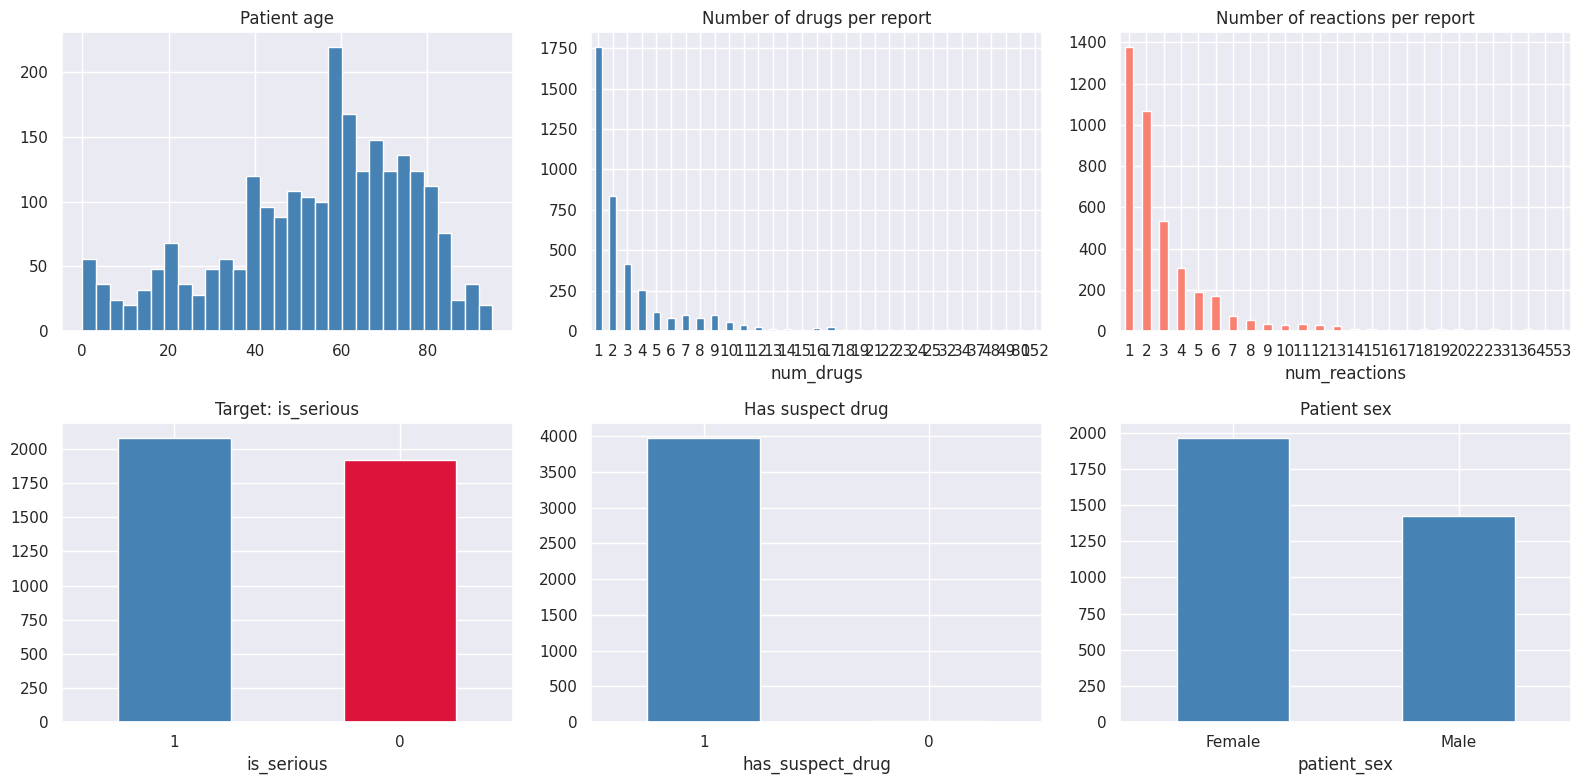

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

df["patient_age"].hist(bins=30, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Patient age")

df["num_drugs"].value_counts().sort_index().plot(kind="bar", ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Number of drugs per report")
axes[0,1].tick_params(axis="x", rotation=0)

df["num_reactions"].value_counts().sort_index().plot(kind="bar", ax=axes[0,2], color="salmon")
axes[0,2].set_title("Number of reactions per report")
axes[0,2].tick_params(axis="x", rotation=0)

df["is_serious"].value_counts().plot(kind="bar", ax=axes[1,0], color=["steelblue", "crimson"])
axes[1,0].set_title("Target: is_serious")
axes[1,0].tick_params(axis="x", rotation=0)

df["has_suspect_drug"].value_counts().plot(kind="bar", ax=axes[1,1], color="steelblue")
axes[1,1].set_title("Has suspect drug")
axes[1,1].tick_params(axis="x", rotation=0)

df["patient_sex"].value_counts().plot(kind="bar", ax=axes[1,2], color="steelblue")
axes[1,2].set_title("Patient sex")
axes[1,2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

FEATURE_COLS = [
    "patient_age", "patient_sex", "country",
    "num_drugs", "num_reactions", "has_suspect_drug",
]
TARGET_COL = "is_serious"

data = df[FEATURE_COLS + [TARGET_COL]].copy()

for col in ["patient_sex", "country"]:
    le = LabelEncoder()
    data[col] = data[col].fillna("Unknown").astype(str)
    data[col] = le.fit_transform(data[col])

for col in ["patient_age", "num_drugs", "num_reactions", "has_suspect_drug"]:
    data[col] = data[col].fillna(data[col].median())

data[TARGET_COL] = data[TARGET_COL].fillna(0).astype(int)

X = data[FEATURE_COLS]
y = data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")
print(f"Serious in test: {y_test.sum()} ({y_test.mean():.1%})")

Train: 3200 rows
Test:  800 rows
Serious in test: 417 (52.1%)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

def evaluate(model, name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model":     name,
        "accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    return model, y_pred, y_prob, metrics

lr, lr_pred, lr_prob, lr_metrics = evaluate(
    LogisticRegression(C=1.0, max_iter=300, random_state=42),
    "Logistic Regression", X_train, X_test, y_train, y_test
)

rf, rf_pred, rf_prob, rf_metrics = evaluate(
    RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "Random Forest", X_train, X_test, y_train, y_test
)

results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("model")
print("\n=== Comparison ===")
print(results)


Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       383
           1       0.94      0.71      0.81       417

    accuracy                           0.83       800
   macro avg       0.85      0.83      0.82       800
weighted avg       0.85      0.83      0.82       800


Random Forest
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       383
           1       0.96      0.76      0.85       417

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.88      0.86      0.86       800


=== Comparison ===
                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.8263     0.9427  0.7098  0.8098   0.8801
Random Forest          0.8575     0.9577  0.7602  0.8476   0.9199


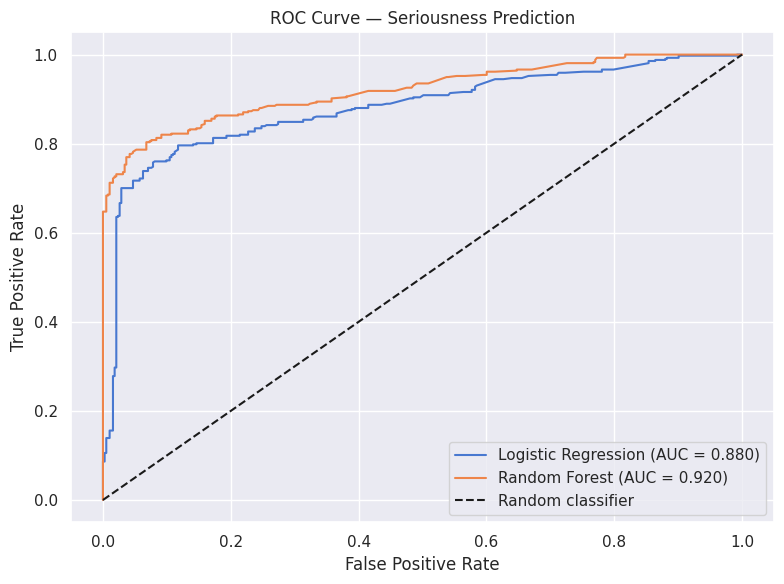

In [15]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [("Logistic Regression", lr_prob), ("Random Forest", rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Seriousness Prediction")
ax.legend()
plt.tight_layout()
plt.show()

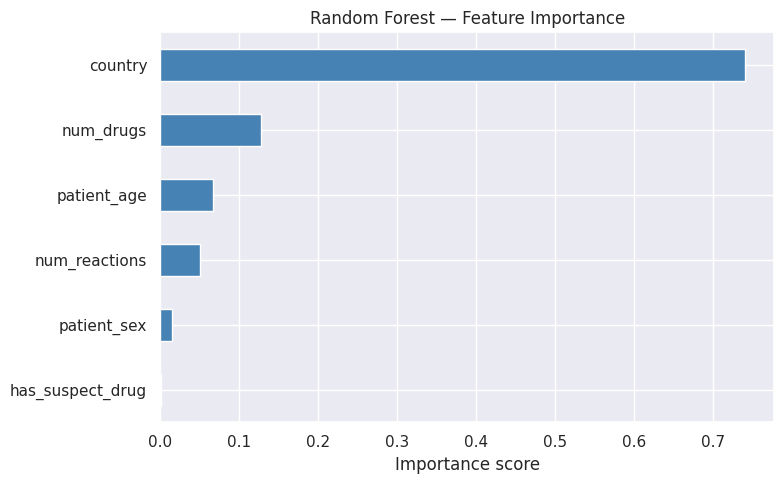


Feature importances:
country             0.739997
num_drugs           0.127847
patient_age         0.066372
num_reactions       0.049866
patient_sex         0.015408
has_suspect_drug    0.000509


In [16]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

print("\nFeature importances:")
print(importances.sort_values(ascending=False).to_string())

In [18]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/9

In [20]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:/content/mlruns")
mlflow.set_experiment("seriousness_prediction")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/30 12:30:32 INFO mlflow.tracking.fluent: Experiment with name 'seriousness_prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/mlruns/268089456367427535', creation_time=1780144232585, experiment_id='268089456367427535', last_update_time=1780144232585, lifecycle_stage='active', name='seriousness_prediction', tags={}, trace_location=None, workspace='default'>

In [21]:
print(mlflow.get_tracking_uri())

file:/content/mlruns


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

mlflow.set_tracking_uri("file:/content/mlruns")
mlflow.set_experiment("seriousness_prediction")

for model, name, params, y_pred, y_prob in [
    (lr, "LogisticRegression", {"C": 1.0, "max_iter": 300}, lr_pred, lr_prob),
    (rf, "RandomForest", {"n_estimators": 100, "max_depth": 6}, rf_pred, rf_prob),
]:
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)

        mlflow.log_metrics({
            "accuracy": round(accuracy_score(y_test, y_pred), 4),
            "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
            "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
            "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
            "roc_auc": round(roc_auc_score(y_test, y_prob), 4),
        })

        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"Logged {name} to MLflow")

print("\nMLflow runs saved locally in Colab at: /content/mlruns")
print("Tracking URI:", mlflow.get_tracking_uri())

2026/05/30 12:32:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 12:32:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/30 12:33:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 12:33:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Logged LogisticRegression to MLflow
Logged RandomForest to MLflow

MLflow runs saved locally in Colab at: /content/mlruns
Tracking URI: file:/content/mlruns


In [24]:
!find /content/mlruns -maxdepth 3 -type d | head -30

/content/mlruns
/content/mlruns/268089456367427535
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101/artifacts
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101/outputs
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101/tags
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101/metrics
/content/mlruns/268089456367427535/b2b1d814c4b64c6695c1076781947101/params
/content/mlruns/268089456367427535/models
/content/mlruns/268089456367427535/models/m-9632c859c522447eb2acbb605b396675
/content/mlruns/268089456367427535/models/m-7e24c50b733346cfa95d3fa6a44f6ab5
/content/mlruns/268089456367427535/9f815931a1384aefaa2521a1593bb626
/content/mlruns/268089456367427535/9f815931a1384aefaa2521a1593bb626/artifacts
/content/mlruns/268089456367427535/9f815931a1384aefaa2521a1593bb626/outputs
/content/mlruns/268089456367427535/9f815931a1384aefaa2521a1593bb626/tags
/content/mlr

In [25]:
print("=== MODEL COMPARISON ===")
print(results.to_string())
best = results["roc_auc"].idxmax()
print(f"\nBest model by ROC-AUC: {best} ({results.loc[best, 'roc_auc']})")
print(f"\nWith only {len(df)} reports, results will be moderate.")
print("More data (multiple months) will improve performance significantly.")

=== MODEL COMPARISON ===
                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.8263     0.9427  0.7098  0.8098   0.8801
Random Forest          0.8575     0.9577  0.7602  0.8476   0.9199

Best model by ROC-AUC: Random Forest (0.9199)

With only 4000 reports, results will be moderate.
More data (multiple months) will improve performance significantly.


In [26]:
import joblib

joblib.dump(rf, "/content/random_forest_seriousness_model.joblib")
print("Saved best model.")

Saved best model.
